<a href="https://colab.research.google.com/github/Shivam-Singh-IN18/Projects_/blob/main/Student_Mark_Prediction/Major_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
#Loading the Dataset
df = pd.read_csv("/content/drive/MyDrive/Major Project/MAJOR PROJECT FINAL /student_performance_dataset.csv")
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [7]:
#Dropping Unnecessary Columns
df = df.drop(columns=['Student_ID', 'Pass_Fail'])

In [8]:
#Checking for Missing Values
df.isnull().sum()

,0
Gender,0
Study_Hours_per_Week,0
Attendance_Rate,0
Past_Exam_Scores,0
Parental_Education_Level,0
Internet_Access_at_Home,0
Extracurricular_Activities,0
Final_Exam_Score,0


In [9]:
#Splitting Features and Target
X = df.drop(columns=['Final_Exam_Score'])
y = df['Final_Exam_Score']

In [10]:
#Defining Categorical and Numerical Features
categorical_features = ['Gender', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities']
numerical_features = ['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores']

In [11]:
#One Hot Encoding for Categorical Variables
preprocessor = ColumnTransformer([('onehot', OneHotEncoder(drop='first'), categorical_features)], remainder='passthrough')

In [12]:
#Train-Test Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Creating Pipeline and Train Model
pipeline = Pipeline([('preprocessing', preprocessor),('regressor', LinearRegression())])
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender',
                                                   'Parental_Education_Level',
                                                   'Internet_Access_at_Home',
                                                   'Extracurricular_Activities'])])),
                ('regressor', LinearRegression())])

In [14]:
#Making Predictions
y_pred = pipeline.predict(X_test)

In [15]:
#Evaluating Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 14.79
R² Score: 0.65


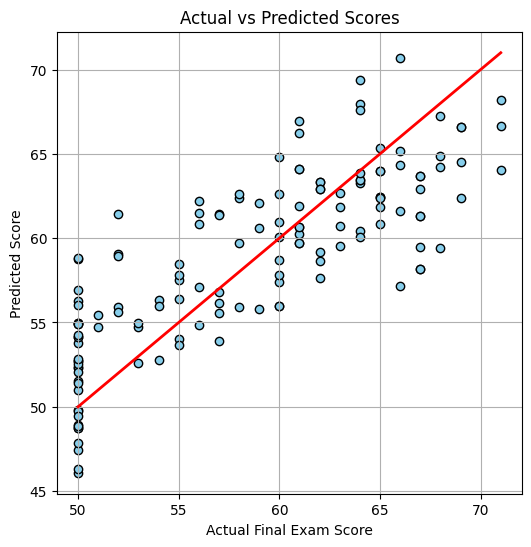

In [16]:
#Visualization of Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, c='skyblue', edgecolors='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)
plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.grid(True)
plt.show()